# Emittance Measurements
## Quadrupole Scan around Waist Current

This notebook performs an emittance analysis from measured data at ALBA Linac, measurements include:
- Experimental current measures `I` and beam size `sigma`
- Machine parameters

The experimental uncertainty is assigned as the last significant digit in every measure.

In [15]:
%pip install uncertainties
import numpy as np
import pandas as pd
from uncertainties import ufloat
import uncertainties.umath as umath
import warnings
from IPython.display import display, HTML
import html
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# ─────────────────────────────────────────────────────────────────────────────
# PARAMETERS
# ─────────────────────────────────────────────────────────────────────────────

E_beam = 80.21 # Beam energy [MeV]
m_e_MeV = 0.51099895 

L_Q = 0.126 # Quadrupole length [m] 
F = 387.65 # [MeV/m^2/A] 

L_drift = 1.235 # From Q1 to FSOTR


# ─────────────────────────────────────────────────────────────────────────────
# MEASURES
# Format: ufloat(value, uncertainity)
# ─────────────────────────────────────────────────────────────────────────────

# QUAD CURRENT [A]
I_labels = [
    r'$I_{\rm waist}+2\Delta I$',
    r'$I_{\rm waist}+\Delta I$',
    r'$I_{\rm waist}$',
    r'$I_{\rm waist}-\Delta I$',
    r'$I_{\rm waist}-2\Delta I$',
]

I_values = [
    ufloat(1.75, 0.1),   # I_waist + 2ΔI  
    ufloat(1.25, 0.1),   # I_waist +  ΔI
    ufloat(0.75, 0.1),   # I_waist
    ufloat(0.25, 0.1),   # I_waist -  ΔI
    ufloat(-0.25, 0.1),   # I_waist - 2ΔI
]

"""
I_values_multibunch-horizontal = [
    ufloat(2.2, 0.1),   # I_waist + 2ΔI  
    ufloat(1.7, 0.1),   # I_waist +  ΔI
    ufloat(1.2, 0.1),   # I_waist
    ufloat( 0.7, 0.1),   # I_waist -  ΔI
    ufloat( 0.2, 0.1),   # I_waist - 2ΔI
]

I_values_multibunch-vertical = [
    ufloat(-0.25, 0.1),   # I_waist + 2ΔI  
    ufloat(-0.75, 0.1),   # I_waist +  ΔI
    ufloat(-1.25, 0.1),   # I_waist
    ufloat(-1.75, 0.1),   # I_waist -  ΔI
    ufloat(-2.25, 0.1),   # I_waist - 2ΔI
]

I_values_singlebunch-horizontal = [
    ufloat(1.75, 0.1),   # I_waist + 2ΔI  
    ufloat(1.25, 0.1),   # I_waist +  ΔI
    ufloat(0.75, 0.1),   # I_waist
    ufloat(0.25, 0.1),   # I_waist -  ΔI
    ufloat(-0.25, 0.1),   # I_waist - 2ΔI
]

I_values_singlebunch-vertical = [
    ufloat(-0.25, 0.1),   # I_waist + 2ΔI  
    ufloat(-0.75, 0.1),   # I_waist +  ΔI
    ufloat(-1.25, 0.1),   # I_waist
    ufloat(-1.75, 0.1),   # I_waist -  ΔI
    ufloat(-2.25, 0.1),   # I_waist - 2ΔI
]
"""

# BEAM SIZE  [mm]
sigma_values= [
    ufloat(0.52, 0.01),    # I_waist + 2ΔI 
    ufloat(0.42, 0.01),    # I_waist +  ΔI
    ufloat(0.38, 0.01),    # I_waist      
    ufloat(0.41, 0.01),    # I_waist -  ΔI
    ufloat(0.48, 0.01),    # I_waist - 2ΔI
]

"""
sigma_values_multibunch-horizontal = [
    ufloat(0.46, 0.01),    # I_waist + 2ΔI 
    ufloat(0.40, 0.01),    # I_waist +  ΔI
    ufloat(0.33, 0.01),    # I_waist      
    ufloat(0.34, 0.01),    # I_waist -  ΔI
    ufloat(0.38, 0.01),    # I_waist - 2ΔI
]

sigma_values_multibunch-vertical = [
    ufloat(0.76, 0.01),    # I_waist + 2ΔI 
    ufloat(0.4, 0.01),    # I_waist +  ΔI
    ufloat(0.091, 0.01),    # I_waist      
    ufloat(0.380, 0.01),    # I_waist -  ΔI
    ufloat(0.72, 0.01),    # I_waist - 2ΔI
]

sigma_values_singlebunch-horizontal = [
    ufloat(0.52, 0.01),    # I_waist + 2ΔI 
    ufloat(0.42, 0.01),    # I_waist +  ΔI
    ufloat(0.38, 0.01),    # I_waist      
    ufloat(0.41, 0.01),    # I_waist -  ΔI
    ufloat(0.48, 0.01),    # I_waist - 2ΔI
]

sigma_values_singlebunch-vertical = [
    ufloat(1.10, 0.01),    # I_waist + 2ΔI 
    ufloat(0.51, 0.01),    # I_waist +  ΔI
    ufloat(0.08, 0.01),    # I_waist      
    ufloat(0.46, 0.01),    # I_waist -  ΔI
    ufloat(1.40, 0.01),    # I_waist - 2ΔI
]
"""


# BUNCH TRAIN

#single bunch data
beam_charge_nC = ufloat(0.04,  0.01)   # [nC]
bunch_train_length_ns= ufloat(2.0, 0.1)   # [ns]
n_bunches = ufloat(1, 0)

""" 
#multi-nunch data
beam_charge_nC = ufloat(0.5,  0.1)   # [nC]
bunch_train_length_ns= ufloat(78, 1)   # [ns]
n_bunches = ufloat(39, 0)
"""


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


' \n#multi-nunch data\nbeam_charge_nC = ufloat(0.5,  0.1)   # [nC]\nbunch_train_length_ns= ufloat(78, 1)   # [ns]\nn_bunches = ufloat(39, 0)\n'

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# CALCULATE QUANTITIES
# ─────────────────────────────────────────────────────────────────────────────

def compute_row(I, sigma_mm,
                F, E_beam, L_Q, L_drift):
    K1 = F * I / E_beam

    K1LQ = K1 * L_Q

    sigma2_mm2 = sigma_mm ** 2
    
    sk = np.sign(K1.nominal_value) * umath.sqrt(umath.fabs(K1))

    Q21 =sk * umath.sin(umath.fabs(sk*L_Q))

    diff_thinlens = (K1LQ - Q21)/Q21 *100

    return {
        'Q21 [m^-1]': Q21,
        'K1*LQ [m^-1]' : K1LQ,
        'sigma [mm]' : sigma_mm,
        'sigma^2 [mm^2]': sigma2_mm2,
        '% diff thin lens': diff_thinlens,
    }

rows = []
for I, sigma_mm in zip(I_values, sigma_values):
    row = compute_row(I, sigma_mm, F, E_beam, L_Q, L_drift)
    rows.append(row)



# ─────────────────────────────────────────────────────────────────────────────
# DISPLAY TABLE
# ─────────────────────────────────────────────────────────────────────────────
def fmt_ufloat(u, decimals=4):
    """Format a ufloat as  'value ± uncertainty'."""
    nom = u.nominal_value
    err = u.std_dev
    return f"{nom:.{decimals}f} ± {err:.{decimals}f}"

def fmt_float(v, decimals=2):
    return f"{v:.{decimals}f}"

# ── Build display table ───────────────────────────────────────────────────────
table_data = []
for lbl, I, r in zip(I_labels, I_values, rows):
    table_data.append({
        'I_quads (A)' : fmt_ufloat(I, 2),
        'Q_21 (m^(-1))' : fmt_ufloat(r['Q21 [m^-1]'], 1),
        'K_1·LQ (m^(-1))' : fmt_ufloat(r['K1*LQ [m^-1]'], 2),
        'σ (mm)': fmt_ufloat(r['sigma [mm]'], 2),
        'σ2 (mm^2)': fmt_ufloat(r['sigma^2 [mm^2]'], 3),
        '% diff thin lens' : fmt_ufloat(r['% diff thin lens'], 2),
    })

index_labels = [
    'I_waist + 2ΔI',
    'I_waist +  ΔI',
    'I_waist',
    'I_waist -  ΔI',
    'I_waist - 2ΔI',
]
df = pd.DataFrame(table_data, index=index_labels)
styled = (
    df.style
    .set_caption('Quadrupole scan around the waist current — Multi-Bunch Mode')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'),
                   ('text-align', 'center'), ('padding-bottom', '8px')]},
        {'selector': 'thead th',
         'props': [('background-color', '#2c3e50'), ('color', 'white'),
                   ('font-size', '12px'), ('text-align', 'center'),
                   ('padding', '6px 10px')]},
        {'selector': 'tbody th',
         'props': [('background-color', '#2c3e50'), ('font-style', 'italic'),
                   ('font-size', '11px'), ('padding', '5px 10px')]},
        {'selector': 'tbody td',
         'props': [('text-align', 'center'), ('font-size', '11px'),
                   ('font-family', 'monospace'), ('padding', '5px 12px')]},
        {'selector': 'tbody tr:hover',
         'props': [('background-color', '#fef9e7')]},
        {'selector': 'table',
         'props': [('border-collapse', 'collapse'), ('margin', 'auto')]},
    ])
)
display(styled)

# ── Build Latex table ───────────────────────────────────────────────────────
table_data = []
for lbl, I, r in zip(I_labels, I_values, rows):
    table_data.append({
        r'$I_\mathrm{quads}$ (A)'       : fmt_ufloat(I, 2),
        r'$Q_{21}$ (m$^{-1}$)'          : fmt_ufloat(r['Q21 [m^-1]'], 1),
        r'$K_1 L_Q$ (m$^{-1}$)'         : fmt_ufloat(r['K1*LQ [m^-1]'], 2),
        r'$\sigma$ (mm)'                 : fmt_ufloat(r['sigma [mm]'], 2),
        r'$\sigma^2$ (mm$^2$)'           : fmt_ufloat(r['sigma^2 [mm^2]'], 3),
        r'\% diff thin lens'             : fmt_ufloat(r['% diff thin lens'], 2),
    })

index_labels_latex = [
    r'$I_w+2\Delta I$',
    r'$I_w+\Delta I$',
    r'$I_w$',
    r'$I_w-\Delta I$',
    r'$I_w-2\Delta I$',
]

df_latex = pd.DataFrame(table_data, index=index_labels_latex)

latex_str = df_latex.to_latex(
    caption='Quadrupole scan around the waist current.',
    label='tab:quadscan',
    position='H',
    escape=False,
    column_format='l' + 'c' * len(df_latex.columns),
)
display(HTML(f"""
<div style='margin-top:10px'>
  <b style='font-family:sans-serif; font-size:13px;'>LaTeX table</b>
  <textarea rows='18' style='width:100%; font-family:monospace; font-size:12px;
      padding:10px; border:1px solid #ccc; border-radius:4px;
      background:#f8f8f8; resize:vertical;'
      onclick='this.select()'>{html.escape(latex_str)}</textarea>
</div>
"""))

,I_quads (A),Q_21 (m^(-1)),K_1·LQ (m^(-1)),σ (mm),σ2 (mm^2),% diff thin lens
I_waist + 2ΔI,1.75 ± 0.10,1.0 ± 0.1,1.07 ± 0.06,0.52 ± 0.01,0.270 ± 0.010,2.27 ± 0.13
I_waist + ΔI,1.25 ± 0.10,0.7 ± 0.1,0.76 ± 0.06,0.42 ± 0.01,0.176 ± 0.008,1.62 ± 0.13
I_waist,0.75 ± 0.10,0.5 ± 0.1,0.46 ± 0.06,0.38 ± 0.01,0.144 ± 0.008,0.97 ± 0.13
I_waist - ΔI,0.25 ± 0.10,0.2 ± 0.1,0.15 ± 0.06,0.41 ± 0.01,0.168 ± 0.008,0.32 ± 0.13
I_waist - 2ΔI,-0.25 ± 0.10,-0.2 ± 0.1,-0.15 ± 0.06,0.48 ± 0.01,0.230 ± 0.010,0.32 ± 0.13


---
## Parabolic fit $\sigma^2$ vs $Q_{21}$
Fit the experimental values to the curve
$$\sigma^2 = A \cdot (q-B)^2 + C $$
and find emittance with $\varepsilon = \sqrt{AC}/d^2$

──────────────────────────────────────────────────
FIT A·(Q₂₁ − B)² + C
 A = 2.9513e-01 ± 2.72e-02 
 B = 3.9862e-01 ± 1.75e-02  (Q_21 at waist)
 C = 1.4453e-01 ± 5.55e-03   (sigma^2_min at waist)
──────────────────────────────────────────────────
 E_kin = 80.210 MeV
 ε     = 0.1354 ± 0.0068  μm·rad
 εn    = 21.39 ± 1.07  μm·rad  (normalised)
──────────────────────────────────────────────────


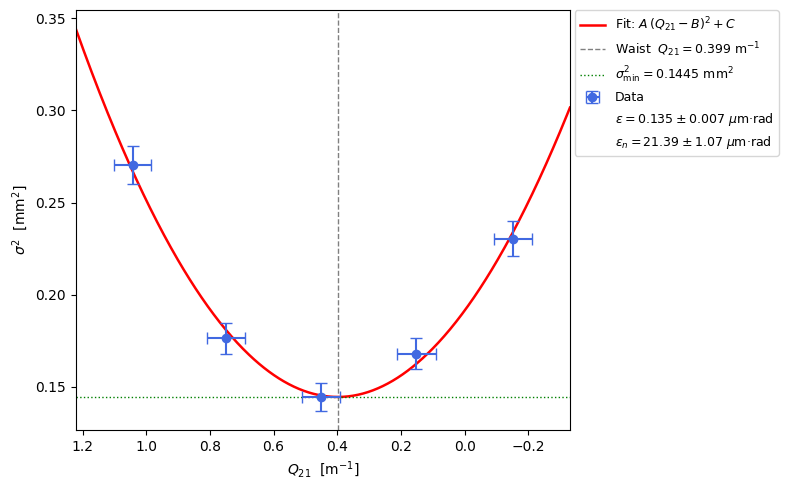

In [18]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

Q21_nom    = np.array([r['Q21 [m^-1]'].nominal_value  for r in rows])
Q21_err    = np.array([r['Q21 [m^-1]'].std_dev for r in rows])
sigma2_nom = np.array([r['sigma^2 [mm^2]'].nominal_value for r in rows])
sigma2_err = np.array([r['sigma^2 [mm^2]'].std_dev for r in rows])

# FIT  A·(Q21 - B)² + C
def parabola_vertex(q, A, B, C):
    return A * (q - B)**2 + C

idx_min = np.argmin(sigma2_nom)
B0 = Q21_nom[idx_min]
C0 = sigma2_nom[idx_min]
A0 = (sigma2_nom.max() - C0) / (Q21_nom.max() - B0)**2

popt, pcov = curve_fit(
    parabola_vertex, Q21_nom, sigma2_nom,
    p0=[A0, B0, C0],
    sigma=sigma2_err, absolute_sigma=True
)
A_fit, B_fit, C_fit = popt
dA, dB, dC = np.sqrt(np.diag(pcov))

# Geometric emittance 
A_SI  = A_fit * 1e-6   
C_SI  = C_fit * 1e-6  
dA_SI = dA * 1e-6
dC_SI = dC * 1e-6

d = L_drift

epsilon_m = np.sqrt(A_SI * C_SI) / d**2
epsilon_um = epsilon_m * 1e6
deps_rel = 0.5 * np.sqrt((dA_SI / A_SI)**2 + (dC_SI / C_SI)**2)
deps_um  = epsilon_um * deps_rel

# Normalised emittance 
m_e_MeV   = 0.511 
E_total   = E_beam + m_e_MeV  
betagamma = np.sqrt(E_total**2 - m_e_MeV**2) / m_e_MeV

epsilon_n_um = betagamma * epsilon_um
deps_n_um    = betagamma * deps_um

print('─' * 50)
print('FIT A·(Q₂₁ − B)² + C')
print(f' A = {A_fit:.4e} ± {dA:.2e} ')
print(f' B = {B_fit:.4e} ± {dB:.2e}  (Q_21 at waist)')
print(f' C = {C_fit:.4e} ± {dC:.2e}   (sigma^2_min at waist)')
print('─' * 50)
print(f' E_kin = {E_beam:.3f} MeV')
print(f' ε     = {epsilon_um:.4f} ± {deps_um:.4f}  μm·rad')
print(f' εn    = {epsilon_n_um:.2f} ± {deps_n_um:.2f}  μm·rad  (normalised)')
print('─' * 50)


# PLOT
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(Q21_nom, sigma2_nom, yerr=sigma2_err, xerr=Q21_err,
            fmt='o', color='royalblue', capsize=4, zorder=3, label='Data')

# Invert x-axis for visual comparision with ALBA control GUI plots
ax.invert_xaxis()

# Extend fit to cover the full axis range with margin
margin  = (Q21_nom.max() - Q21_nom.min()) * 0.15
x_left  = Q21_nom.max() + margin
x_right = Q21_nom.min() - margin  

q_fine           = np.linspace(x_left, x_right, 500)
sigma2_fit_curve = parabola_vertex(q_fine, *popt)

ax.plot(q_fine, sigma2_fit_curve, 'r-', lw=1.8,
        label=r'Fit: $A\,(Q_{21} - B)^2 + C$')
ax.axvline(B_fit, color='gray',  ls='--', lw=1,
           label=rf'Waist  $Q_{{21}} = {B_fit:.3f}$ m$^{{-1}}$')
ax.axhline(C_fit, color='green', ls=':',  lw=1,
           label=rf'$\sigma^2_{{\min}} = {C_fit:.4f}$ mm$^2$')
ax.set_xlim(x_left, x_right)

handles, labels = ax.get_legend_handles_labels()
for txt, val, err, dec in [
    (r'$\varepsilon', epsilon_um, deps_um, 3),
    (r'$\varepsilon_n', epsilon_n_um, deps_n_um, 2),
]:
    handles.append(plt.Line2D(
        [0], [0], color='none',
        label=rf'{txt} = {val:.{dec}f} \pm {err:.{dec}f}\ \mu$m·rad'
    ))
ax.legend(
    handles=handles,
    loc='upper left',
    bbox_to_anchor=(1.01, 1.0),
    borderaxespad=0,
    fontsize=9,
    frameon=True,
)
ax.set_xlabel(r'$Q_{21}$  [m$^{-1}$]')
ax.set_ylabel(r'$\sigma^2$  [mm$^2$]')

plt.tight_layout()
plt.savefig('quad_scan_plot.png', dpi=150, bbox_inches='tight')
plt.show()